# Preprocessing and clustering

In [1]:
import anndata as ad
import pooch
import scanpy as sc

In [2]:
sc.set_figure_params(dpi=50, facecolor="white")

The data used in this basic preprocessing and clustering tutorial was collected from bone marrow mononuclear cells of healthy human donors and was part of [openproblem's NeurIPS 2021 benchmarking dataset](https://openproblems.bio/competitions/neurips_2021/) {cite}`luecken2021`. The samples used in this tutorial were measured using the 10X Multiome Gene Expression and Chromatin Accessability kit. 


We are reading in the count matrix into an [AnnData](https://anndata.readthedocs.io/en/latest/tutorials/notebooks/getting-started.html) object, which holds many slots for annotations and different representations of the data.

In [3]:
def download_sample(sample_id: str, known_hash: str) -> ad.AnnData:
    path = pooch.retrieve(
        path=pooch.os_cache("scverse_tutorials"),
        url=f"https://exampledata.scverse.org/tutorials/neurips-2021/{sample_id}_filtered_feature_bc_matrix.h5",
        known_hash=known_hash,
    )
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    return sample_adata


samples = {
    "s1d1": "md5:a99285913ea3f3d22600d3d2f8a88e34",
    "s1d3": "md5:825f7f7578e3dc0b8955f5a97a402338",
}
adatas = {id_: download_sample(id_, known_hash) for id_, known_hash in samples.items()}
adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()

/home/rezkuh/.local/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/rezkuh/.local/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/rezkuh/.local/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


The data contains 8,785 cells and 36,601 measured genes. This tutorial includes a basic preprocessing and clustering workflow. 

## Quality Control

The scanpy function {func}`~scanpy.pp.calculate_qc_metrics` calculates common quality control (QC) metrics, which are largely based on `calculateQCMetrics` from scater {cite}`McCarthy2017`. One can pass specific gene population to {func}`~scanpy.pp.calculate_qc_metrics` in order to calculate proportions of counts for these populations. Mitochondrial, ribosomal and hemoglobin genes are defined by distinct prefixes as listed below. 

In [4]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")  # "MT-" for human, "Mt-" for mouse
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [5]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

One can now inspect violin plots of some of the computed QC metrics:

* the number of genes expressed in the count matrix
* the total counts per cell
* the percentage of counts in mitochondrial genes

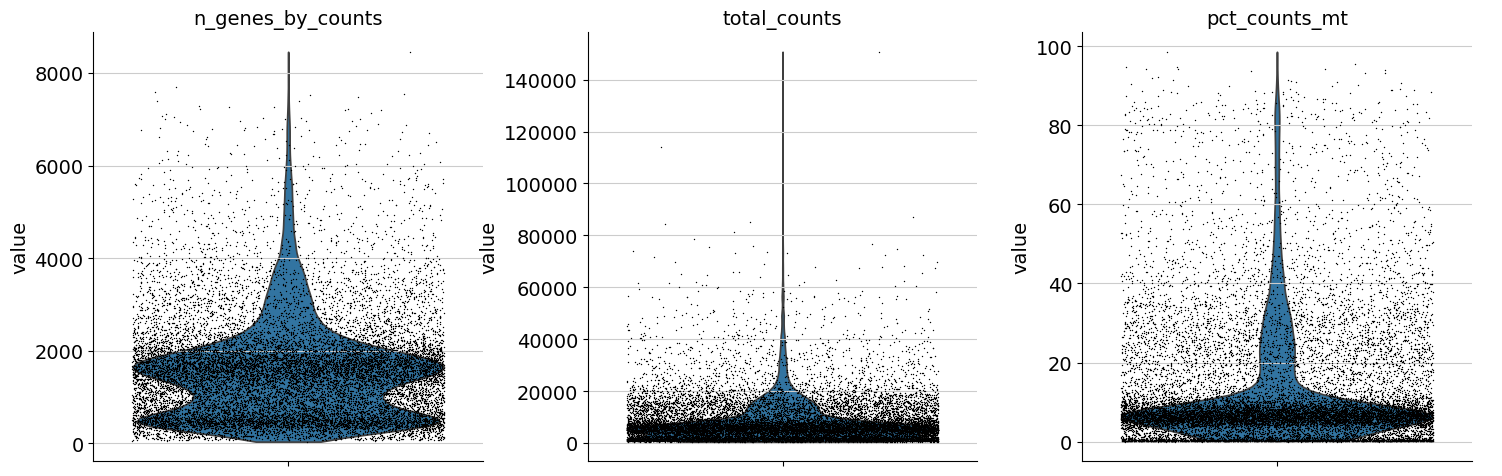

In [6]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)

Additionally, it is useful to consider QC metrics jointly by inspecting a scatter plot colored by `pct_counts_mt`. 

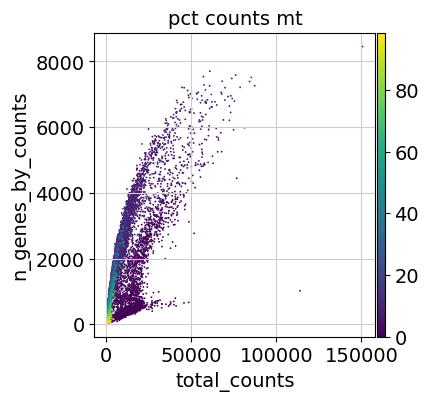

In [7]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

Based on the QC metric plots, one could now remove cells that have too many mitochondrial genes expressed or too many total counts by setting manual or automatic thresholds. However, it proved to be beneficial to apply a very permissive filtering strategy in the beginning for your single-cell analysis and filter low quality cells during clustering or revisit the filtering again at a later point. We therefore now only filter cells with less than 100 genes expressed and genes that are detected in less than 3 cells. 

Additionally, it is important to note that for datasets with multiple batches, quality control should be performed for each sample individually as quality control thresholds can very substantially between batches. 

In [8]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

### Doublet detection

As a next step, we run a doublet detection algorithm. Identifying doublets is crucial as they can lead to misclassifications or distortions in downstream analysis steps. Scanpy contains the doublet detection method Scrublet {cite}`Wolock2019`. Scrublet predicts cell doublets using a nearest-neighbor classifier of observed transcriptomes and simulated doublets. {func}`scanpy.pp.scrublet` adds `doublet_score` and `predicted_doublet` to `.obs`. One can now either filter directly on `predicted_doublet` or use the `doublet_score` later during clustering to filter clusters with high doublet scores. 

In [9]:
pip install scrublet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
#sc.pp.scrublet(adata, batch_key="sample")
sc.external.pp.scrublet(adata, batch_key="sample")

/home/rezkuh/.local/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number
/home/rezkuh/.local/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Automatically set threshold at doublet score = 0.23
Detected doublet rate = 2.5%
Estimated detectable doublet fraction = 31.4%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 8.0%


/home/rezkuh/.local/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number
/home/rezkuh/.local/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Automatically set threshold at doublet score = 0.61
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 4.7%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 5.4%


:::{seealso}
Alternative methods for doublet detection within the scverse ecosystem are [DoubletDetection](https://github.com/JonathanShor/DoubletDetection) and [SOLO](https://docs.scvi-tools.org/en/stable/user_guide/models/solo.html). You can read more about these in the [Doublet Detection chapter](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#doublet-detection) of Single Cell Best Practices.
:::

## Normalization

The next preprocessing step is normalization. A common approach is count depth scaling with subsequent log plus one (log1p) transformation. Count depth scaling normalizes the data to a “size factor” such as the median count depth in the dataset, ten thousand (CP10k) or one million (CPM, counts per million). The size factor for count depth scaling can be controlled via `target_sum` in `pp.normalize_total`. We are applying median count depth normalization with log1p transformation (AKA log1PF).

In [11]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [12]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data:
sc.pp.log1p(adata)

## Feature selection

As a next step, we want to reduce the dimensionality of the dataset and only include the most informative genes. This step is commonly known as feature selection. The scanpy function `pp.highly_variable_genes` annotates highly variable genes by reproducing the implementations of Seurat {cite}`Satija2015`, Cell Ranger {cite}`Zheng2017`, and Seurat v3 {cite}`stuart2019comprehensive` depending on the chosen `flavor`. 

In [13]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

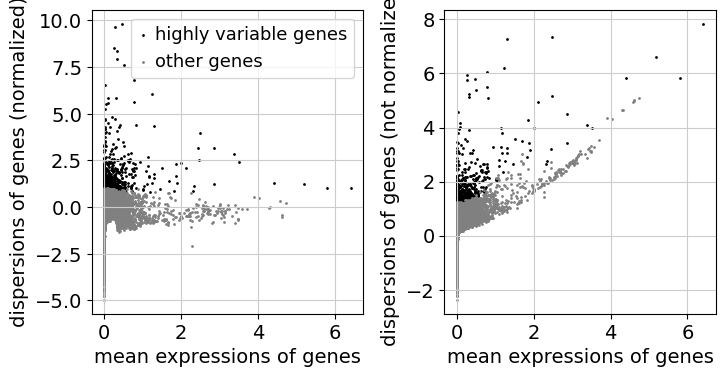

In [14]:
sc.pl.highly_variable_genes(adata)

## Dimensionality Reduction
Reduce the dimensionality of the data by running principal component analysis (PCA), which reveals the main axes of variation and denoises the data.

In [15]:
sc.tl.pca(adata)

Let us inspect the contribution of single PCs to the total variance in the data. This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells, e.g. used in the clustering function {func}`~scanpy.tl.leiden` or {func}`~scanpy.tl.tsne`. In our experience, often a rough estimate of the number of PCs does fine.

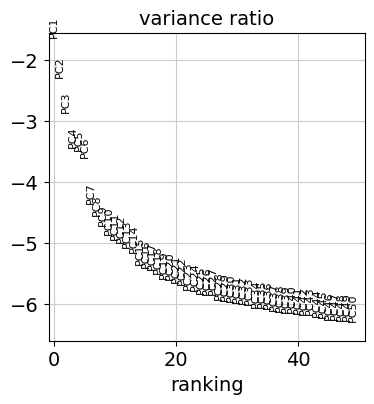

In [16]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

## Visualization

Let us compute the neighborhood graph of cells using the PCA representation of the data matrix.

In [17]:
sc.pp.neighbors(adata)

2026-04-05 03:48:26.799574: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 03:48:26.938322: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 03:48:28.034475: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


We suggest embedding the graph in two dimensions using UMAP (McInnes et al., 2018), see below. 

In [18]:
sc.tl.umap(adata)

We can now visualize the UMAP according to the `sample`. 

/home/rezkuh/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


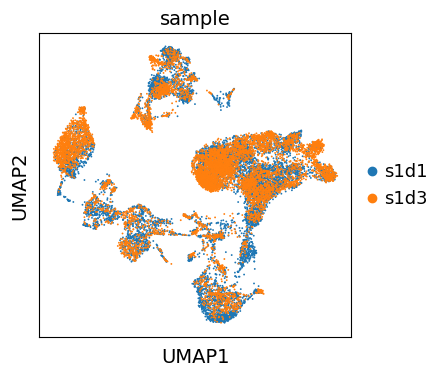

In [19]:
sc.pl.umap(adata, color="sample")

Even though the data considered in this tutorial includes two different samples, we only observe a minor batch effect and we can continue with clustering and annotation of our data. 

If you inspect batch effects in your UMAP it can be beneficial to integrate across samples and perform batch correction/integration. 

## Clustering

As with Seurat and many other frameworks, we recommend the Leiden graph-clustering method (community detection based on optimizing modularity) {cite}`traag2019louvain`. Note that Leiden clustering directly clusters the neighborhood graph of cells, which we already computed in the previous section.

In [20]:
pip install leidenalg

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install --upgrade scanpy igraph leidenalg

Defaulting to user installation because normal site-packages is not writeable
  Using cached leidenalg-0.11.0-cp38-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (10 kB)
INFO: pip is looking at multiple versions of leidenalg to determine which version is compatible with other requirements. This could take a while.
Note: you may need to restart the kernel to use updated packages.


In [23]:
#sc.tl.leiden(adata, flavor="igraph")
sc.tl.leiden(adata)

/home/rezkuh/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


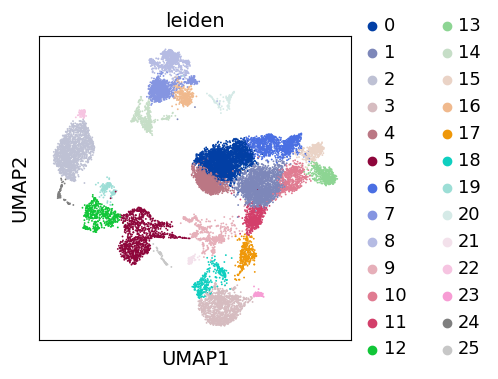

In [25]:
sc.pl.umap(adata, color=["leiden"])

## Re-assess quality control and cell filtering 

As indicated before, we will now re-assess our filtering strategy by visualizing different QC metrics using UMAP. 

/home/rezkuh/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/rezkuh/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


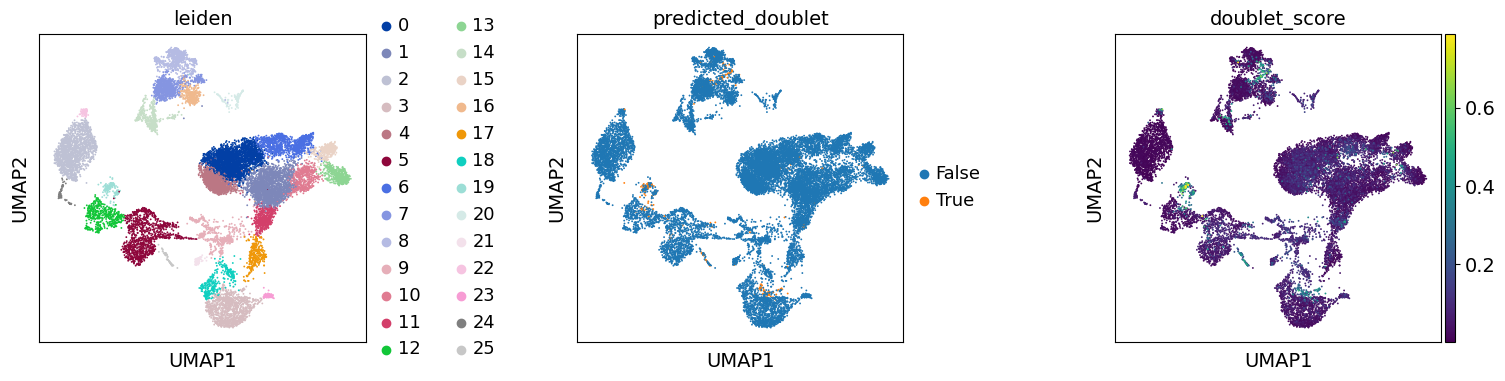

In [26]:
adata.obs["predicted_doublet"] = adata.obs["predicted_doublet"].astype("category")
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
)

We can now subset the AnnData object to exclude cells predicted as doublets: 

In [27]:
adata = adata[~adata.obs["predicted_doublet"].to_numpy()].copy()

/home/rezkuh/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


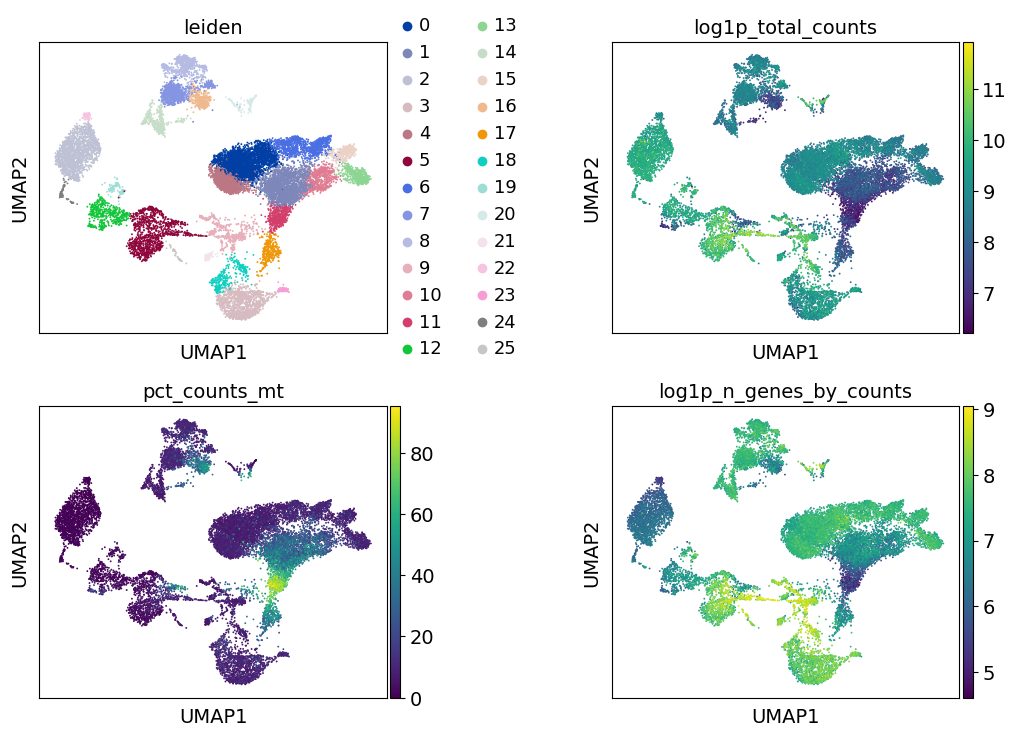

In [28]:
sc.pl.umap(
    adata, color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"], wspace=0.5, ncols=2
)

## Cell-type annotation

In [32]:
!pip install celltypist
!pip install decoupler

Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 369.6 kB/s eta 0:00:00a 0:00:01
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Defaulting to user installation because normal site-packages is not writeable


In [33]:
import celltypist as ct
import decoupler as dc

We have now reached a point where we have obtained a set of cells with decent quality, and we can proceed to their annotation to known cell types. Typically, this is done using genes that are exclusively expressed by a given cell type, or in other words these genes are the marker genes of the cell types, and are thus used to distinguish the heterogeneous groups of cells in our data. Previous efforts have collected and curated various marker genes into available resources, such as [CellMarker](http://bio-bigdata.hrbmu.edu.cn/CellMarker/), [TF-Marker](http://bio.liclab.net/TF-Marker/), and [PanglaoDB](https://panglaodb.se/).

Commonly and classically, cell type annotation uses those marker genes subsequent to the grouping of the cells into clusters. So, let's generate a set of clustering solutions which we can then use to annotate our cell types. Here, we will use the Leiden clustering algorithm which will extract cell communities from our nearest neighbours graph.

In [35]:
sc.tl.leiden(adata, key_added="leiden_res0_02", resolution=0.02)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res2", resolution=2)

Notably, the number of clusters that we define is largely arbitrary, and so is the `resolution` parameter that we use to control for it. As such, the number of clusters is ultimately bound to the stable and biologically-meaningful groups that we can ultimately distringuish, typically done by experts in the corresponding field or by using expert-curated prior knowledge in the form of markers.

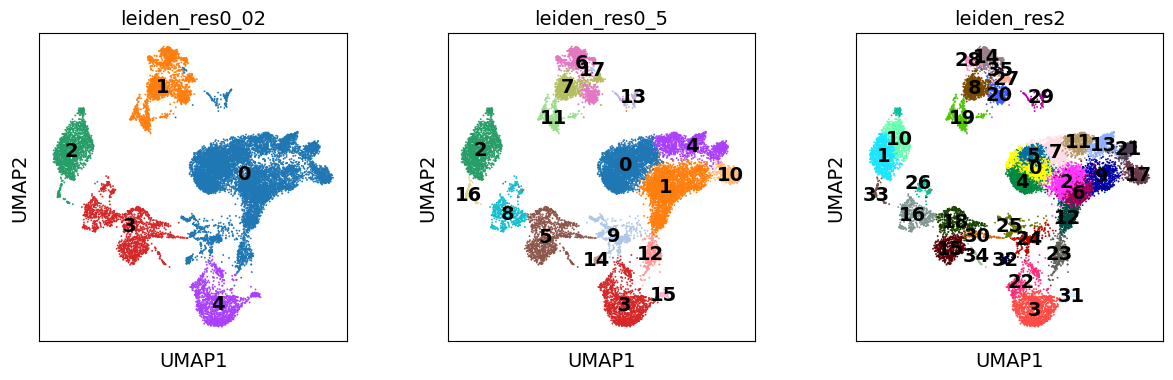

In [36]:
sc.pl.umap(
    adata,
    color=["leiden_res0_02", "leiden_res0_5", "leiden_res2"],
    legend_loc="on data",
)

Though UMAPs should not be over-interpreted, here we can already see that in the highest resolution our data is over-clustered, while the lowest resolution is likely grouping cells which belong to distinct cell identities.

### Marker gene set

Let's define a set of marker genes for the main cell types that we expect to see in this dataset. These were adapted from [Single Cell Best Practices annotation chapter](https://www.sc-best-practices.org/cellular_structure/annotation.html), for a more detailed overview and best practices in cell type annotation, we refer the user to it.

In [37]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": ["MS4A1", "ITGB1", "COL4A4", "PRDM1", "IRF4", "PAX5", "BCL11A", "BLK", "IGHD", "IGHM"],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],  # Note PAX5 is a negative marker
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

In [38]:
def group_max(adata: sc.AnnData, groupby: str) -> str:
    import pandas as pd

    agg = sc.get.aggregate(adata, by=groupby, func="mean")
    return pd.Series(agg.layers["mean"].sum(1), agg.obs[groupby]).idxmax()

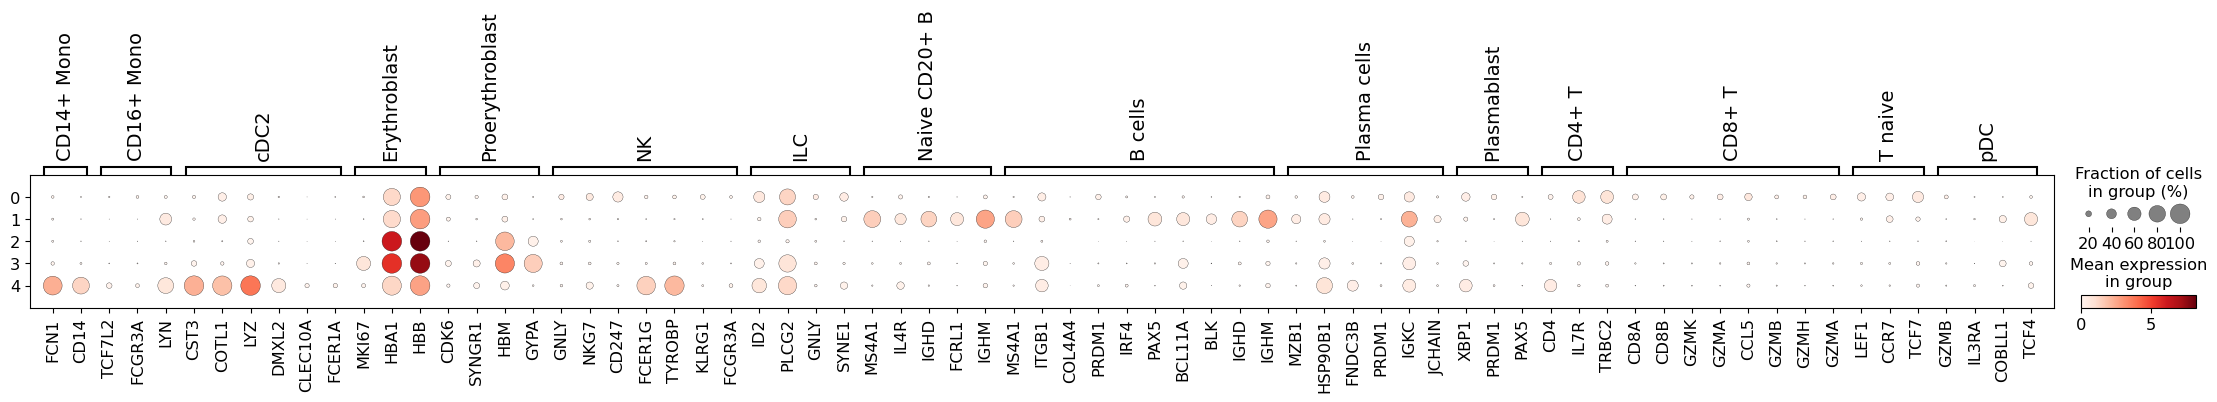

In [39]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res0_02")

Here, we can see that cluster {eval}`group_max(adata[:, marker_genes["NK"]], "leiden_res0_02")` perhaps contains an admixture of monocytes and dendritic cells, while in cluster {eval}`group_max(adata[:, marker_genes["B cells"]], "leiden_res0_02")` we have different populations of B lymphocytes. Thus, we should perhaps consider a higher clustering resolution.

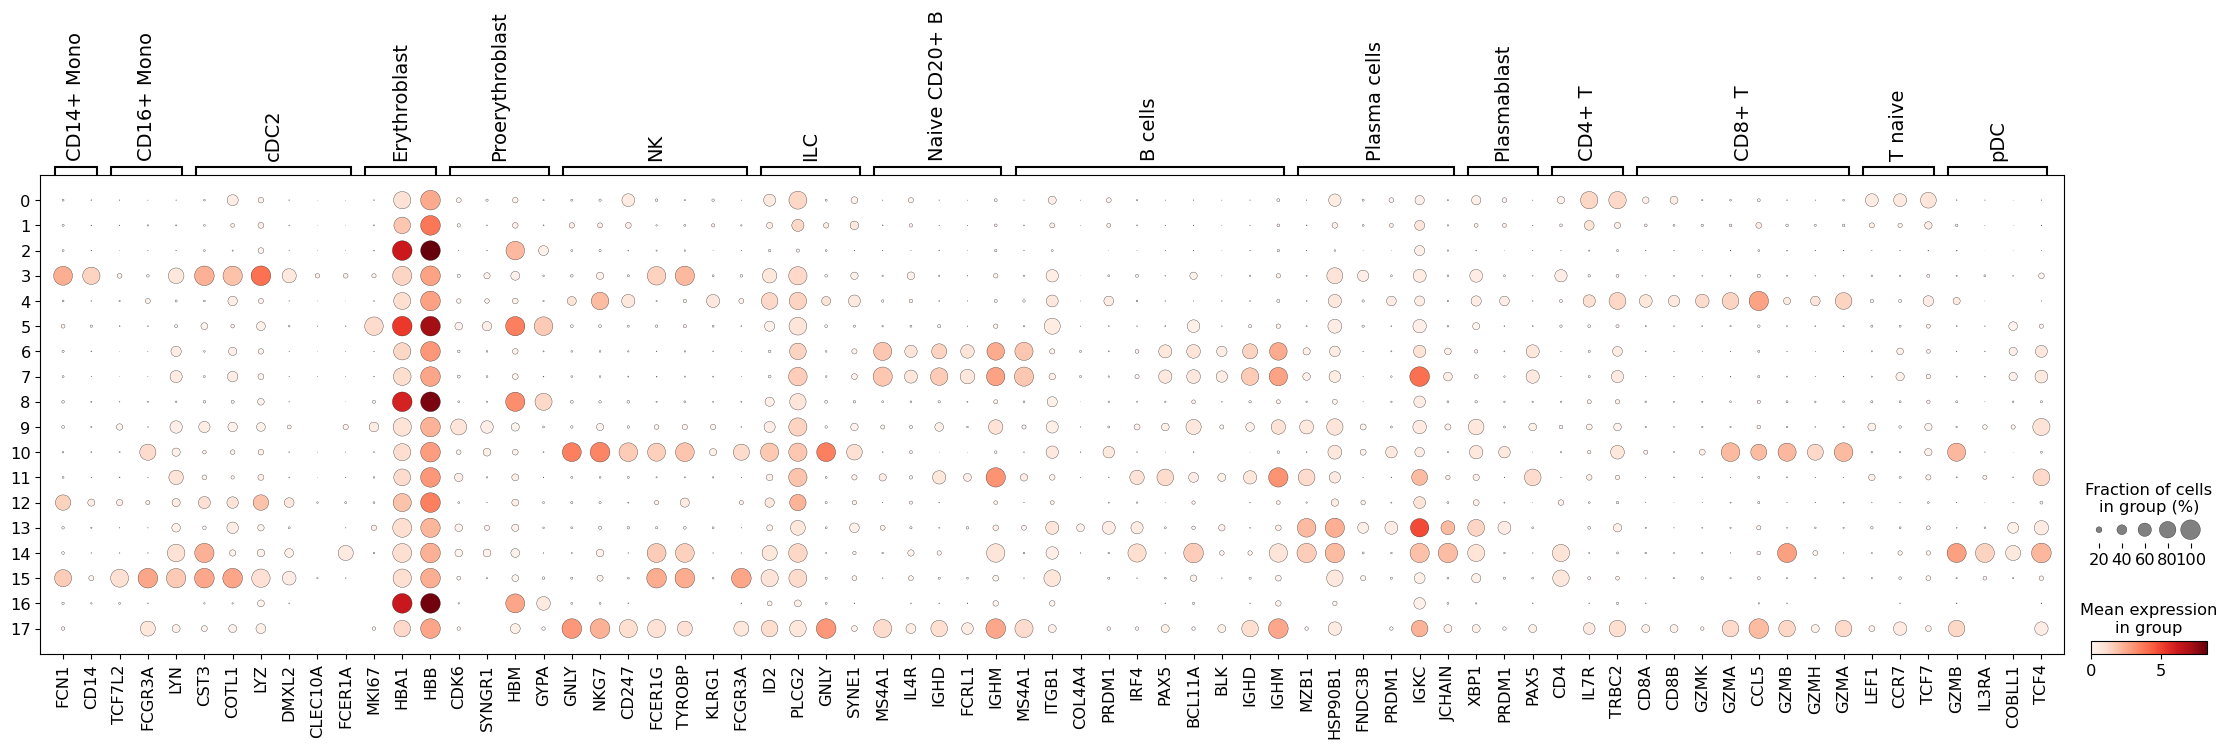

In [40]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res0_5")

This seems like a resolution that suitable to distinguish most of the different cell types in our data. Ideally, one would look specifically into each cluster, and attempt to subcluster those if required.

### Automatic label prediction

In addition to using marker collections to annotate our labels, there exist approaches to automatically annotate scRNA-seq datasets. One such tool is [CellTypist](https://github.com/Teichlab/celltypist), which uses gradient-descent optimised logistic regression classifiers to predict cell type annotations.

First, we need to retrive the CellTypist models that we wish to use, in this case we will use models with immune cell type and subtype populations generated using 20 tissues from 18 studies ([Domínguez Conde, et al. 2022](https://www.science.org/doi/full/10.1126/science.abl5197)). 

In [41]:
ct.models.download_models(model=["Immune_All_Low.pkl"], force_update=True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /home/rezkuh/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl


📂 Storing models in /home/runner/.celltypist/data/models


💾 Total models to download: 1


💾 Downloading model [1/1]: Immune_All_Low.pkl


Then we predict the major cell type annotations. In this case we will enable `majority_voting`, which will assign a label to the clusters that we obtained previously.

In [42]:
model = ct.models.Model.load(model="Immune_All_Low.pkl")
predictions = ct.annotate(adata, model="Immune_All_Low.pkl", majority_voting=True, over_clustering="leiden_res0_5")
# convert back to anndata||
adata = predictions.to_adata()

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 16801 cells and 23427 genes
🔗 Matching reference genes in the model
🧬 5852 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


🔗 Matching reference genes in the model


🧬 5852 features used for prediction


⚖️ Scaling input data


🖋️ Predicting labels


✅ Prediction done!


🗳️ Majority voting the predictions


✅ Majority voting done!


Let's examine the results of automatic clustering:

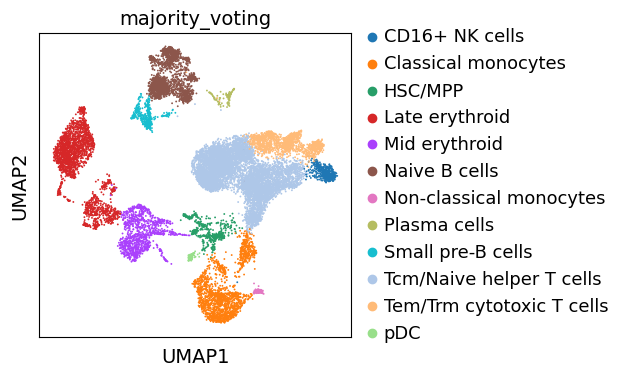

In [43]:
sc.pl.umap(adata, color="majority_voting", ncols=1)

Note that our previously 'Unknown' cluster is now assigned as 'Pro-B cells'.

### Annotation with enrichment analysis

Automatic cell type labelling with methods that require pre-trained models will not always work as smoothly, as such classifiers need to be trained on and be representitive for a given tissue and the cell types within it. So, as a more generalizable approach to annotate the cells, we can also use the marker genes from any database, for example [PanglaoDB](https://panglaodb.se/). Here we will use it with simple multi-variate linear regression, implemented in [decoupler](https://github.com/saezlab/decoupler-py). Essentially, this will test if any collection of genes are enriched in any of the cells. Ultimately, this approach is similar to many other marker-based classifiers.

Let's get canonical cell markers using with [decoupler](https://github.com/saezlab/decoupler-py) which queries the OmniPath metadata-base to obtain the [PanglaoDB](https://panglaodb.se/) marker gene database with cannonical cell type markers.

In [47]:
pip install omnipath

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py) ... done
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19885 sha256=2c0185525e096c16672bf3423958d513eb691826658332524a2b5af0fb0cbf55
  Stored in directory: /home/rezkuh/.cache/pip/wheels/48/f0/c9/3928c369e4e0aae8c3daa3c36e5ddf982aed49d3196addc1f0
Successfully built docrep
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
botocore 1.35.6 requires urllib3<1.27,>=1.25.4; python_version < "3.10", but you have urllib3 2.2.3 which is incompatible.
tensorflow 2.13.1 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.13.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [50]:
import decoupler as dc

# 1. Fetch
markers = dc.get_resource("PanglaoDB")

# 2. Debug: Look for the column that specifies Human vs Mouse
# Common columns are 'taxon', 'ncbitaxonid', 'species', or 'organism'
possible_org_cols = ['taxon', 'ncbitaxonid', 'species', 'organism']
org_col = next((c for c in possible_org_cols if c in markers.columns), None)

if org_col:
    # Filter for Human (Taxon 9606 or name 'human')
    is_human = markers[org_col].astype(str).str.lower().isin(['human', '9606', 'hsapiens'])
    
    # Check for canonical markers - if column missing, skip this filter
    if "canonical_marker" in markers.columns:
        markers = markers[is_human & (markers["canonical_marker"])]
    else:
        markers = markers[is_human]
else:
    print("Could not find an organism column. Columns present are:", markers.columns.tolist())

# 3. Deduplicate (PanglaoDB uses 'genesymbol' or 'target' for the gene name)
gene_col = 'genesymbol' if 'genesymbol' in markers.columns else 'target'
markers = markers[~markers.duplicated(["cell_type", gene_col])]

markers.head()

Could not find an organism column. Columns present are: ['genesymbol', 'canonical_marker', 'cell_type', 'germ_layer', 'human', 'human_sensitivity', 'human_specificity', 'mouse', 'mouse_sensitivity', 'mouse_specificity', 'ncbi_tax_id', 'organ', 'ubiquitiousness']


,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
0,CTRB1,False,Enterocytes,Endoderm,True,0.000000,0.004394,True,0.003311,0.020480,9606,GI tract,0.017
1,CTRB1,True,Acinar cells,Endoderm,True,1.000000,0.000629,True,0.957143,0.015920,9606,Pancreas,0.017
2,KLK1,False,Distal tubule cells,Mesoderm,True,0.000000,0.008145,True,0.851064,0.011649,9606,Kidney,0.013
3,KLK1,True,Endothelial cells,Mesoderm,True,0.000000,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013
4,KLK1,True,Acinar cells,Endoderm,True,0.833333,0.005031,True,0.314286,0.012826,9606,Pancreas,0.013


In [54]:
import decoupler as dc

# Set weight=None to bypass the weight requirement
dc.run_mlm(
    adata, 
    net=markers.rename(columns=dict(cell_type="source", genesymbol="target")), 
    weight=None,
    use_raw=False,
    verbose=True
)

Running mlm on mat with 16801 samples and 23427 targets for 158 sources.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:43<00:00, 21.56s/it]


mlm - fitting 118 multivariate models of 23427 observations with 23308 degrees of freedom


100%|██████████| 1/1 [00:29<00:00, 29.20s/it]

100%|██████████| 1/1 [00:29<00:00, 29.20s/it]


mlm - done


The obtained results are stored in `.obsm`, with `"score_mlm"` representing coefficient t-values, and `"padj_mlm"` representing adjusted p-values.:

In [58]:
#adata.obsm["score_mlm"].head()

# View the first few rows of the MLM activity scores
#print(adata.obsm["mlm_estimate"].head())

adata.obsm["score_mlm"] = adata.obsm["mlm_estimate"]
adata.obsm["score_mlm"].head()

,Distal tubule cells,Endothelial cells,Acinar cells,Goblet cells,Plasmacytoid dendritic cells,Principal cells,Epithelial cells,Enterocytes,Paneth cells,Fibroblasts,...,Taste receptor cells,Neuroendocrine cells,Parathyroid chief cells,Retinal ganglion cells,Enterochromaffin cells,Urothelial cells,GABAergic neurons,Follicular cells,Ionocytes,Decidual cells
AAACCCAAGGATGGCT-1,-0.232594,-0.661465,-0.806855,0.162241,-0.454273,-0.855668,-1.299583,-1.077845,-1.387363,0.480319,...,-0.698815,-0.290649,-0.117029,-0.771583,-0.532057,-0.718752,0.276168,-0.840220,-0.288837,0.231395
AAACCCAAGGCCTAGA-1,-0.507196,-0.149373,0.598786,-0.145790,0.366481,0.066776,-2.015072,-1.979792,0.823622,1.759147,...,-0.751582,-0.156802,0.055235,-1.069197,-0.633231,-0.987212,0.445668,-0.470078,0.054830,0.319464
AAACCCAAGTGAGTGC-1,1.036757,-0.439930,0.545895,0.926935,-1.427479,0.025269,-1.531388,-0.980072,0.561133,0.371574,...,-0.556293,-0.561129,-0.097372,-0.234006,-0.029188,-0.416503,-0.142774,-0.597961,2.232781,-0.995162
AAACCCACAAGAGGCT-1,-0.754734,-0.244545,-1.518447,0.938046,12.091487,-1.704441,-1.857917,-1.294521,-1.092417,1.944786,...,-0.431291,-0.578934,-0.353177,-1.427035,-0.993335,-0.951291,1.236677,-0.943191,1.023588,2.045516
AAACCCACATCGTGGC-1,-0.344888,0.843339,1.308399,-0.155836,-1.308663,0.667160,-0.502956,0.050584,-0.667083,2.529423,...,1.794862,0.920297,0.116007,1.397454,-0.822584,-0.302886,-0.021652,-0.557977,0.054802,-1.332843


To visualize the obtianed scores, we can re-use any of scanpy’s plotting functions. 
First though, we will extract them from the adata object.

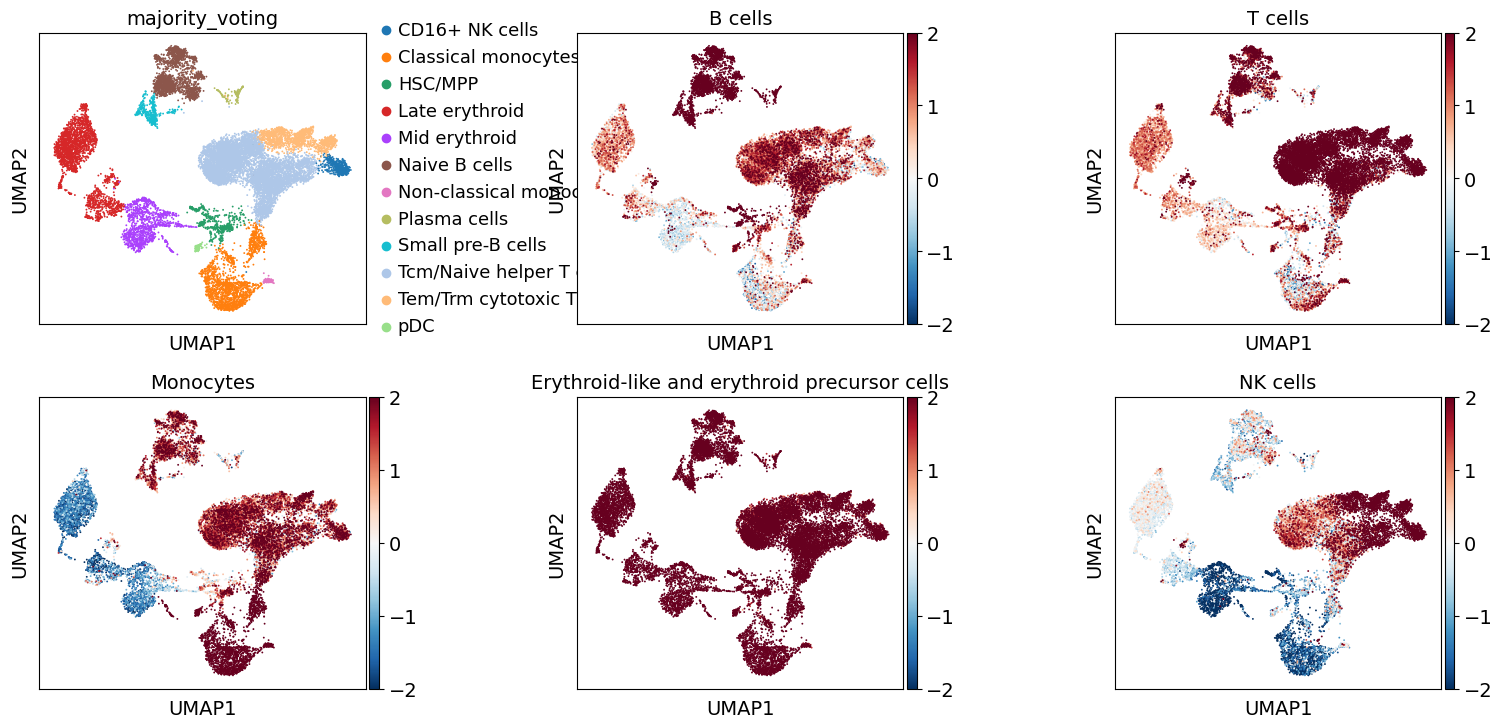

In [60]:
import decoupler as dc
import scanpy as sc

# 1. Get the activity object using the correct function and key
# Note: Ensure "mlm_estimate" is the key in your adata.obsm
acts = dc.get_acts(adata, obsm_key="mlm_estimate")

# 2. Transfer metadata from original adata to the acts object 
# so you can plot "majority_voting" alongside the scores
acts.obs['majority_voting'] = adata.obs['majority_voting']

# 3. Plot the UMAP
sc.pl.umap(
    acts,
    color=[
        "majority_voting",
        "B cells",
        "T cells",
        "Monocytes",
        "Erythroid-like and erythroid precursor cells",
        "NK cells",
    ],
    wspace=0.5,
    ncols=3,
    cmap='RdBu_r', # Red-Blue is standard for showing enrichment/depletion
    vmin=-2,
    vmax=2
)

These results further confirm the our automatic annotation with Celltypist. In addition, here we can also transfer the max over-representation score estimates to assign a label to each cluster.

In [64]:
import pandas as pd

# 1. Create a temporary DataFrame of the activity scores
# acts.X contains the MLM scores, acts.var_names are the cell types
df_acts = pd.DataFrame(acts.X, index=acts.obs_names, columns=acts.var_names)

# 2. Add the cluster labels to this DataFrame
df_acts['cluster'] = adata.obs['leiden_res0_5']

# 3. Calculate the mean score for every cell type in every cluster
df_means = df_acts.groupby('cluster').mean()

# 4. For each cluster, find the cell type with the highest average score
annotation_dict = df_means.idxmax(axis=1).to_dict()

# 5. Map the labels back to your original data
adata.obs["dc_anno"] = adata.obs["leiden_res0_5"].map(annotation_dict)

# Print the mapping to verify
print("Final Cluster Annotations:")
for cluster, cell_type in annotation_dict.items():
    print(f"Cluster {cluster}: {cell_type}")

Final Cluster Annotations:
Cluster 0: T memory cells
Cluster 1: Erythroid-like and erythroid precursor cells
Cluster 2: Erythroid-like and erythroid precursor cells
Cluster 3: Monocytes
Cluster 4: T cells
Cluster 5: Erythroid-like and erythroid precursor cells
Cluster 6: B cells naive
Cluster 7: B cells naive
Cluster 8: Erythroid-like and erythroid precursor cells
Cluster 9: Pancreatic progenitor cells
Cluster 10: NK cells
Cluster 11: B cells
Cluster 12: Monocytes
Cluster 13: Plasma cells
Cluster 14: Plasmacytoid dendritic cells
Cluster 15: Monocytes
Cluster 16: Erythroid-like and erythroid precursor cells
Cluster 17: B cells naive


Let's compare all resulting annotations here

... storing 'dc_anno' as categorical


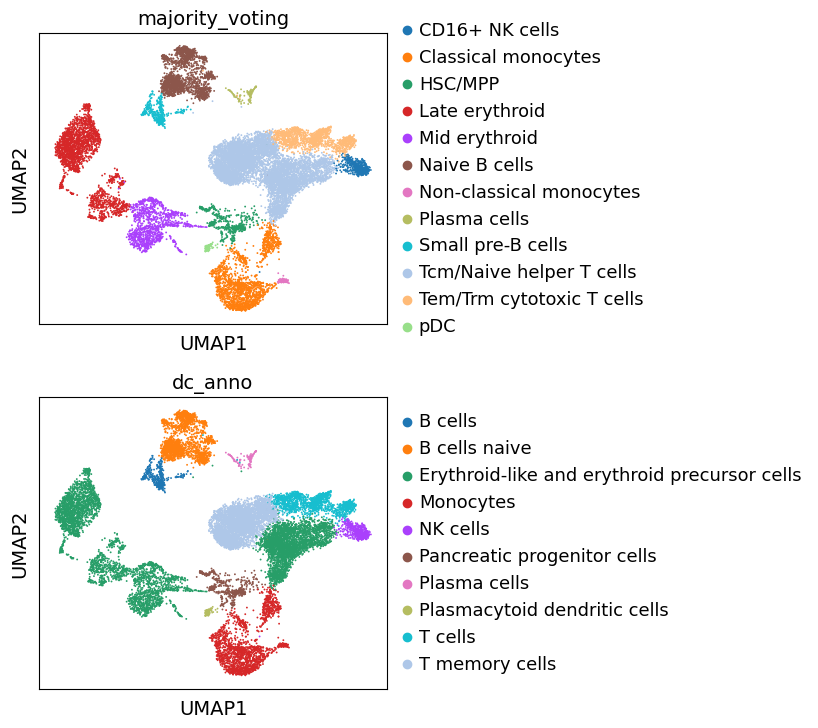

In [65]:
sc.pl.umap(adata, color=["majority_voting", "dc_anno"], ncols=1)

Great. We can see that the different approaches to annotate the data are largely concordant. Though, these annotations are decent, cell type annotation is laborous and repetitive task, one which typically requires multiple rounds of sublucstering and re-annotation. Nevertheless, we now have a good basis with which we can further proceed with manually refining our annotations. 

### Differentially-expressed Genes as Markers

Furthermore, one can also calculate marker genes per cluster and then look up whether we can link those marker genes to any known biology, such as cell types and/or states. This is typically done using simple statistical tests, such as Wilcoxon and t-test, for each cluster vs the rest.

In [66]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res0_5")
# Filter those
sc.tl.filter_rank_genes_groups(adata, min_fold_change=1.5)

We can then visualize the top 5 differentially-expressed genes on a dotplot.

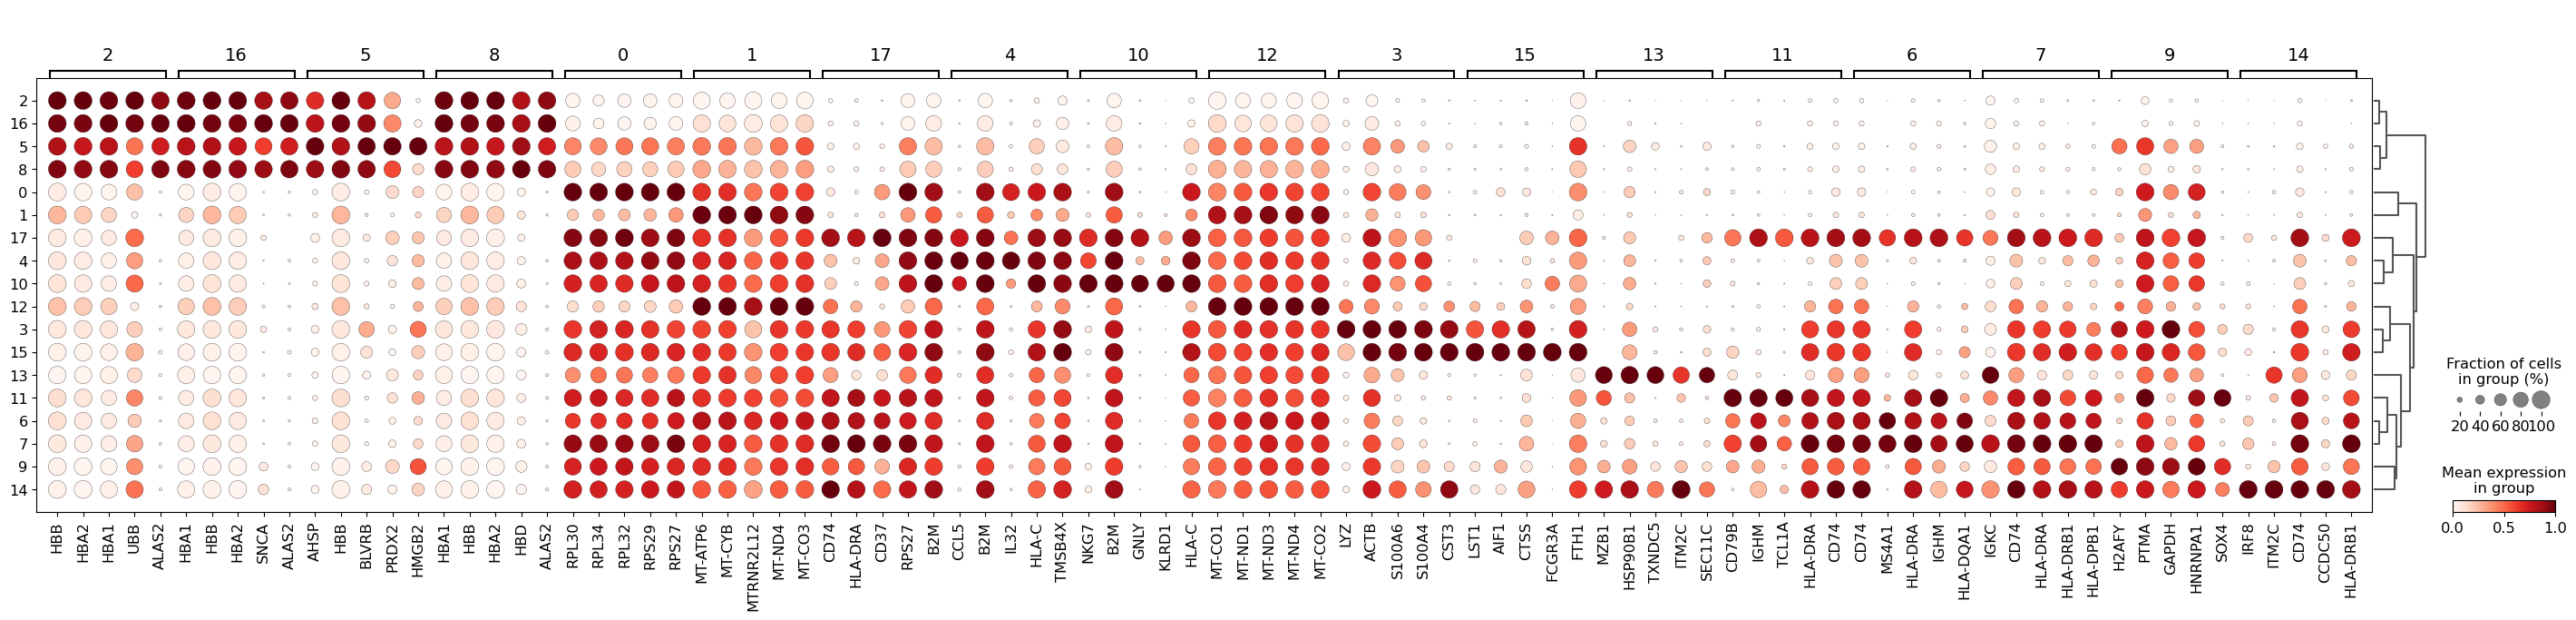

In [67]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_res0_5", standard_scale="var", n_genes=5)

We see that *LYZ*, *ACT8*, *S100A6*, *S100A4*, and *CST3* are all highly expressed in cluster `3`.
Let's visualize those at the UMAP space:

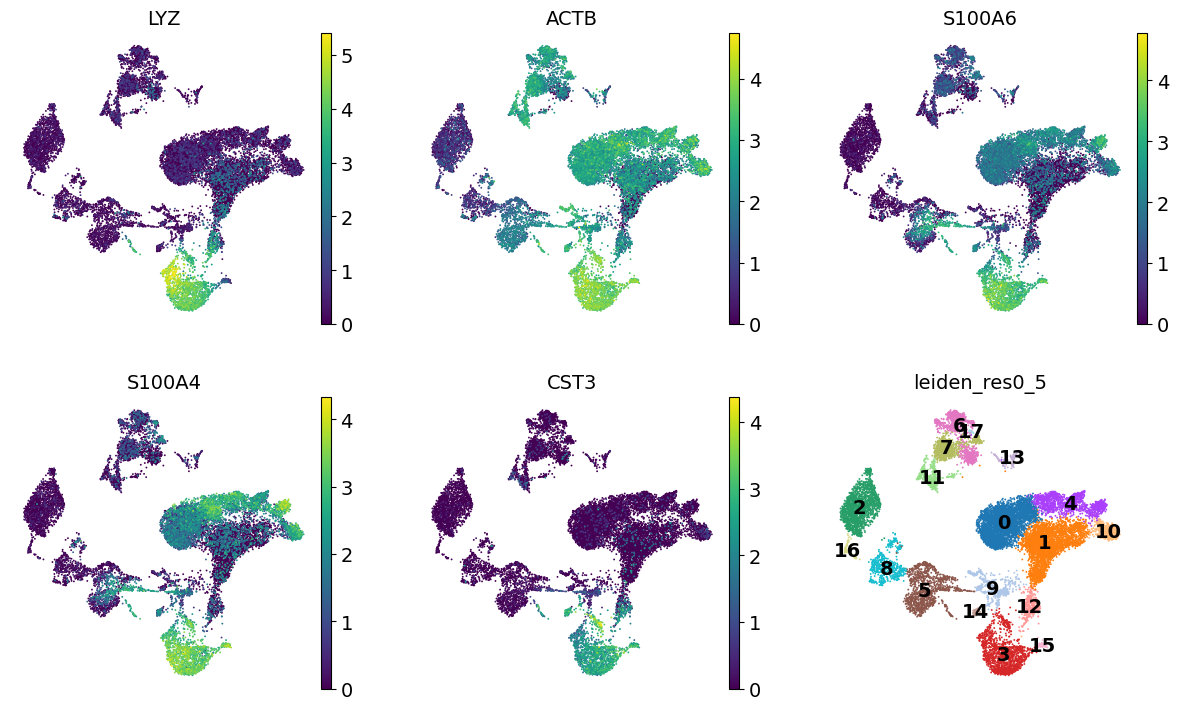

In [68]:
cluster3_genes = ["LYZ", "ACTB", "S100A6", "S100A4", "CST3"]
sc.pl.umap(adata, color=[*cluster3_genes, "leiden_res0_5"], legend_loc="on data", frameon=False, ncols=3)

Similarly, we can also generate a Violin plot with the distrubtions of the same genes across the clusters.

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

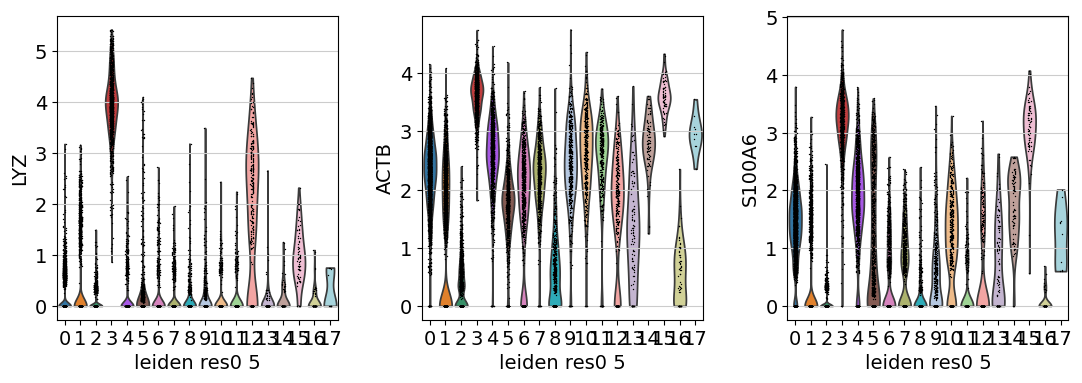

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


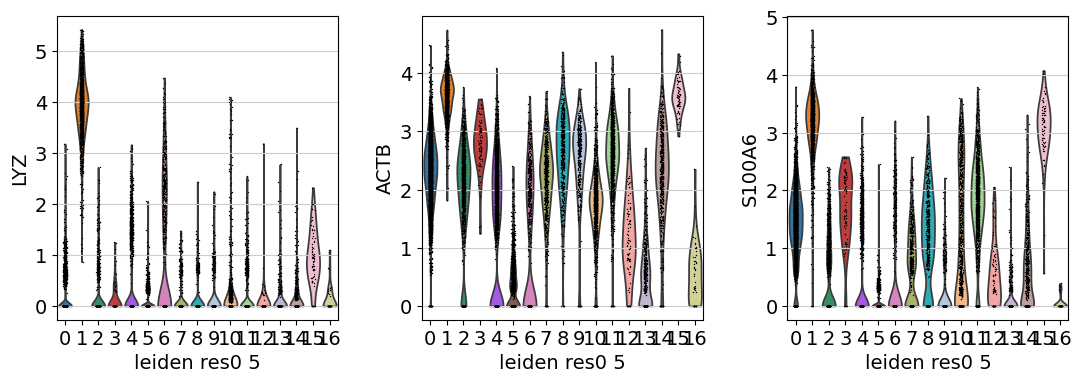

In [69]:
sc.pl.violin(adata, keys=cluster3_genes[0:3], groupby="leiden_res0_5", multi_panel=True)